# BV Algo 


1001


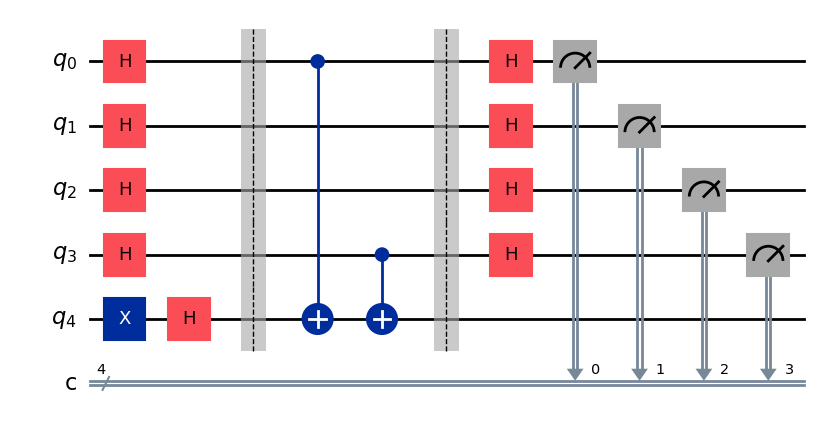

In [ ]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator 

def dj(qubits, secret):
    qc = QuantumCircuit(qubits + 1, qubits)
    qc.h(range(qubits))
    qc.x(qubits)
    qc.h(qubits)
    qc.barrier()
    qc = qc.compose(secret)
    qc.barrier()
    qc.h(range(qubits))
    qc.measure(range(qubits), range(qubits)) # barring the last qubit measures the rest
    result = AerSimulator().run(qc, shots=100, memory=True).result()
    return result.get_memory()[0], qc


def secretCircuit(secret): 
    n = len(secret)
    qc = QuantumCircuit(n+1, n)
    for i, qubit in enumerate(secret):
        if qubit == "1":
            qc.cx(i, n)
    return qc

secretQc = secretCircuit("1001")
output, qc = dj(4, secretQc)
print(output)
display(qc.draw('mpl'))